### Time_Series_Forecast

Shows how selective reporting can make model seem to be better.

Also why MAPE is bad, and how to make stable WAPE error function.

In [1]:
import os, sys, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

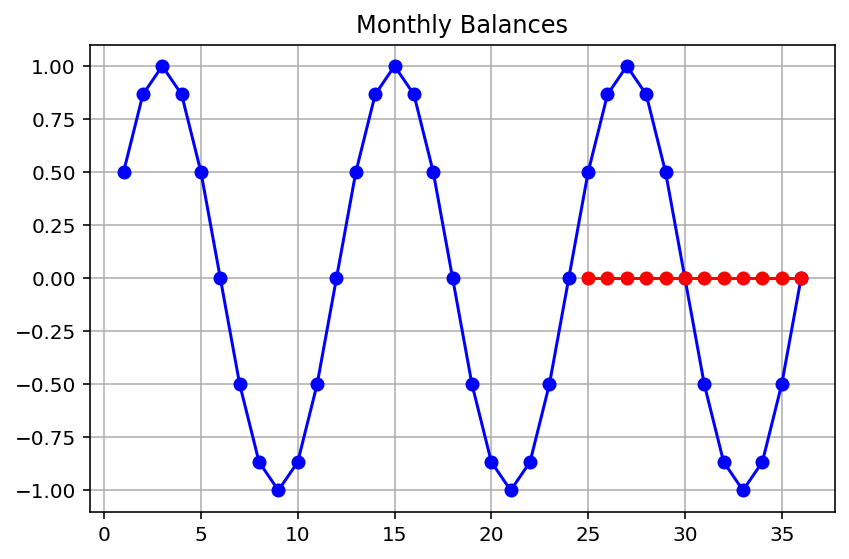

In [2]:
# suppose we have actual values for 3 years (36 months)
months = np.arange(1, 37, 1)
vals   = np.sin(months*2*math.pi/12.0)

# Suppose that we use first 24 months 
# to train a simple forecasting model.
# It is so trivial - it predicts zero values.

months_pred = np.arange(25, 37, 1)
vals_pred   = np.full(12,0)         # 12 points with 0 values 

fig, ax = plt.subplots(figsize=(6,4))
_ = ax.plot(months, vals, color="blue", marker='o')
_ = ax.plot(months_pred, vals_pred, color="red", marker='o')
_ = ax.set_title(f"Monthly Balances")
_ = ax.grid(True)

fig.tight_layout()
plt.show() ; # semicolon needed to remove text output on top

In [3]:
print(vals[24:].shape)
print(vals_pred.shape)

(12,)
(12,)


In [4]:
# Let's calculate the WAPE of the prediction
# https://www.baeldung.com/cs/mape-vs-wape-vs-wmape
# also see discussion at the bottom

# ----------------------------------------------------
def wape (actual, predicted, y_norm = None):
    """
    # calculate custom WAPE
    # (Weighted Absolute Percentage Error)
    # between two arrays (or lists)
    # y_norm (when provided) used as denominator
    """
    Na = len(actual)
    Np = len(predicted)
    if Na == 0 or Np == 0 or Na != Np:
        return np.nan
    nomin = np.abs(actual - predicted).sum()
    if y_norm and y_norm > 0:
        return nomin / (y_norm * Na)
    # -----------------------------
    v_max, v_min = np.max(actual), np.min(actual)
    v_amp   = v_max-v_min    # amplitude
    v_scale = np.abs(actual).sum() / Na
    if (v_amp <= 1e-4 * v_scale):
        return 0.0
    # -----------------------------
    # v_amp is reasonably large, shift in units of v_amp
    shifted = (actual - v_min) + 5*v_amp
    denom = np.abs(shifted).sum()
    return nomin / denom

# ----------------------------------------------------
def mape (actual, predicted):
    Na = len(actual)
    Np = len(predicted)
    if Na == 0 or Np == 0 or Na != Np:
        return np.nan
    actual_sum = np.absolute(actual).sum()
    if actual_sum <= 0:
        return np.nan
    mysum = 0
    for ii in range(Na):
        a = actual[ii]
        p = predicted[ii]
        c = a if np.absolute(a) > 0.0001 else 0.0001
        v = np.absolute((a-p)/c) / Na
        if v > 20:
            print(f"a={a:.4f}, p={p:.4f}, c={c:.4f}, v={v:.4f}")
        mysum += v
    return mysum

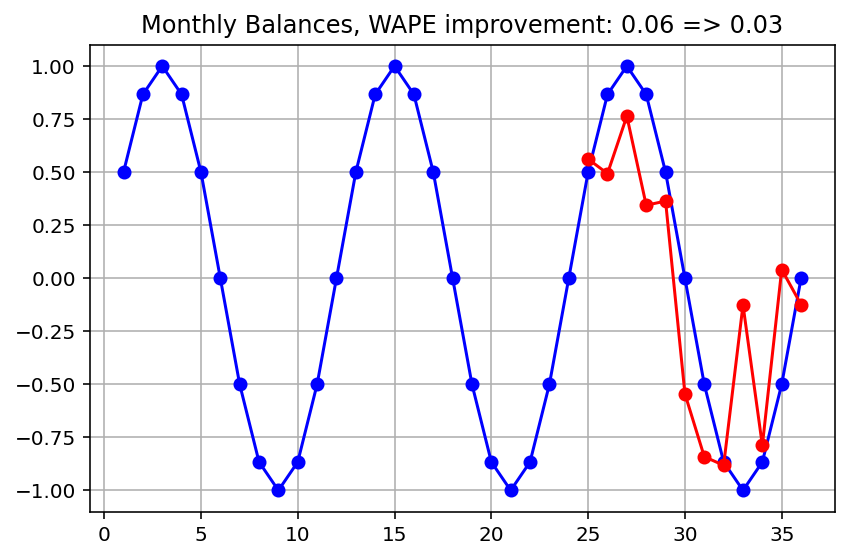

In [5]:
# Now let's try to improve prediction by using randomness

wape_best = wape(vals[24:], vals_pred)
wape_best_orig = wape_best
vals_best = np.full(12,0) 

N = 1000
for counter in range(N):
    vals_temp = 1.8*(np.random.rand(12) - 0.5)
    wape_temp = wape(vals[24:], vals_temp)
    if wape_temp < wape_best:
        wape_best = wape_temp
        vals_best = vals_temp

# print(f"WAPE improvement: {wape_best_orig} => {wape_best}")
fig, ax = plt.subplots(figsize=(6,4))
_ = ax.plot(months, vals, color="blue", marker='o')
_ = ax.plot(months_pred, vals_best, color="red", marker='o')
_ = ax.set_title(f"Monthly Balances, "+f"WAPE improvement: {wape_best_orig:.2f} => {wape_best:.2f}")
_ = ax.grid(True)

fig.tight_layout()
plt.show() ; # semicolon needed to remove text output on top

### Error Function Selection

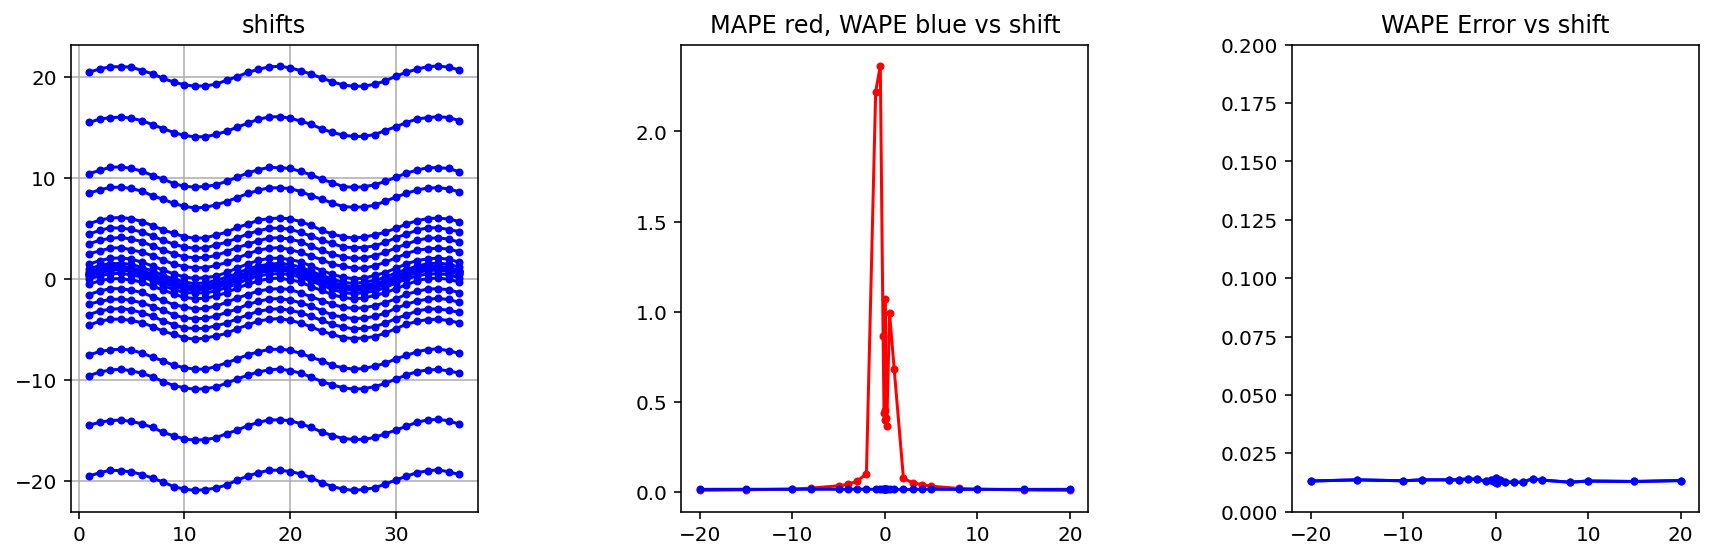

In [6]:
months = np.arange(1, 37, 1)
vals   = np.sin(months*2*math.pi/15.0)
levels = [-20,-15,-10,-8,-5,-4,-3,
          -2,-1,-0.5,-0.2,-0.1,0.05,0,0.05,0.1,0.2,0.5,1,2,
          3,4,5,8,10,15,20]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))
ax0, ax1, ax2 = ax.flatten()

_ = ax0.set_title(f"shifts")
_ = ax1.set_title(f"MAPE red, WAPE blue vs shift")
_ = ax2.set_title(f"WAPE Error vs shift")
_ = ax0.grid(True)

errs_mape = []
errs_wape = []
for level in levels:
    rand_arr = 0.1*np.random.rand(len(vals))
    vals1 = vals+level+rand_arr
    vals2 = vals+level+0.2 # second ("predicted") curve shifted by 10% of amplitude
    errs_mape.append(round(mape(vals1,vals2),4))
    errs_wape.append(round(wape(vals1,vals2),4))
    _ = ax0.plot(months, vals1, color="blue", marker='.')  
    
_ = ax1.plot(levels, errs_mape, color="red" , marker='.')
_ = ax1.plot(levels, errs_wape, color="blue", marker='.')
_ = ax2.plot(levels, errs_wape, color="blue", marker='.')
_ = ax2.plot(levels, errs_wape, color="blue", marker='.')
_ = ax2.set(ylim=(0.0, max(0.2, np.max(errs_wape))))

fig.tight_layout()
plt.subplots_adjust(wspace=0.50, hspace=1.0)
plt.show() ; 

In [7]:
mape_max = np.max(errs_mape)
mape_min = np.min(errs_mape)
wape_max = np.max(errs_wape)
wape_min = np.min(errs_wape)

print(f"MAPE max/min = {mape_max:9.4f} / {mape_min:6.4f} = {(mape_max/mape_min):11,.4f}")
print(f"WAPE max/min = {wape_max:9.4f} / {wape_min:6.4f} = {(wape_max/wape_min):11,.4f}")

MAPE max/min =    2.3633 / 0.0074 =    319.3649
WAPE max/min =    0.0142 / 0.0124 =      1.1452


In [8]:
print("WAPE:")
for v in errs_wape:
    print(f"{v:.4f}", end=",")
print()
print("MAPE:")
for v in errs_mape:
    print(f"{v:.4f}", end=",")
print()

WAPE:
0.0131,0.0136,0.0132,0.0136,0.0136,0.0136,0.0141,0.0138,0.0130,0.0135,0.0130,0.0127,0.0142,0.0135,0.0133,0.0124,0.0127,0.0134,0.0128,0.0125,0.0127,0.0141,0.0135,0.0126,0.0131,0.0129,0.0133,
MAPE:
0.0075,0.0104,0.0152,0.0197,0.0332,0.0411,0.0590,0.1003,2.2212,2.3633,0.8671,0.4395,0.4546,1.0694,0.3973,0.4084,0.3642,0.9911,0.6814,0.0741,0.0494,0.0398,0.0304,0.0179,0.0146,0.0094,0.0074,


### So MAPE is really bad (can spike to very big numbers)

### How we made error estimates more stable